# LongBench Baseline Analysis — Qasper-E

This notebook compares two KV-cache formats using the complete Qasper-E evaluation set:

- **FP16 KV cache**: `kv_cache_dtype="auto"`
- **INT8 KV cache**: `kv_cache_dtype="int8_per_token_head"`

The same 224 examples, prompts, model weights, and generation settings are used for both runs.

The analysis focuses on dataset context lengths, overall QA quality, per-example quality changes, quality by context length, end-to-end latency, and representative answer changes.

The measured latency includes both prompt prefill and autoregressive decoding. It should therefore be interpreted as **end-to-end request time**, not decode-only latency.

## 1. Load and validate the results

The first step verifies that both runs contain exactly the same 224 examples, with no duplicates and identical prompt lengths.

In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

PROJECT_ROOT = Path.home() / "kv_cache_project"
RESULTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "original_vllm"
    / "longbench"
    / "qasper_e_full"
)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AUTO_CSV = RESULTS_DIR / "qasper_e_full_auto.csv"
INT8_CSV = RESULTS_DIR / "qasper_e_full_int8_per_token_head.csv"
AUTO_JSONL = RESULTS_DIR / "qasper_e_full_auto.jsonl"
INT8_JSONL = RESULTS_DIR / "qasper_e_full_int8_per_token_head.jsonl"


def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise RuntimeError(
                    f"Invalid JSON on line {line_number} of {path}"
                ) from error
    return pd.DataFrame(records)

required_files = [AUTO_CSV, INT8_CSV, AUTO_JSONL, INT8_JSONL]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing result files:\n" + "\n".join(str(path) for path in missing_files)
    )

auto_metrics = pd.read_csv(AUTO_CSV)
int8_metrics = pd.read_csv(INT8_CSV)
auto_outputs = load_jsonl(AUTO_JSONL)
int8_outputs = load_jsonl(INT8_JSONL)

for name, dataframe in {
    "FP16 CSV": auto_metrics,
    "INT8 CSV": int8_metrics,
    "FP16 JSONL": auto_outputs,
    "INT8 JSONL": int8_outputs,
}.items():
    assert len(dataframe) == 224, f"{name} does not contain 224 examples"
    assert dataframe["dataset_index"].nunique() == 224, (
        f"{name} contains duplicate or missing indices"
    )

assert set(auto_metrics["dataset_index"]) == set(int8_metrics["dataset_index"])

prompt_check = auto_metrics[["dataset_index", "prompt_tokens"]].merge(
    int8_metrics[["dataset_index", "prompt_tokens"]],
    on="dataset_index",
    suffixes=("_fp16", "_int8"),
    validate="one_to_one",
)
assert (
    prompt_check["prompt_tokens_fp16"]
    == prompt_check["prompt_tokens_int8"]
).all()

print("Validation passed: 224 paired Qasper-E examples.")

Validation passed: 224 paired Qasper-E examples.


## 2. Dataset context-length distribution

This section shows the range of context lengths represented in the benchmark.

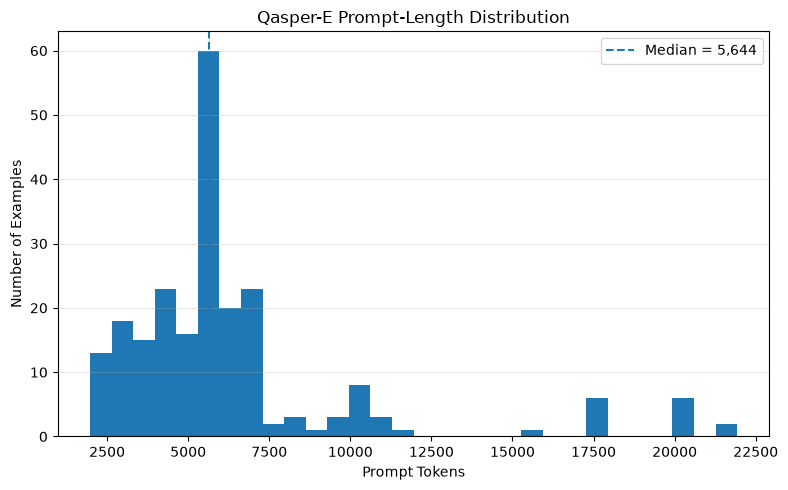

In [2]:
prompt_tokens = auto_metrics["prompt_tokens"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(prompt_tokens, bins=30)
ax.axvline(
    prompt_tokens.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {prompt_tokens.median():,.0f}",
)
ax.set_title("Qasper-E Prompt-Length Distribution")
ax.set_xlabel("Prompt Tokens")
ax.set_ylabel("Number of Examples")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = FIGURES_DIR / "qasper_e_prompt_length_distribution_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

## 3. Build the paired quality and performance data

Qasper-E quality is measured using token-level F1. Predictions and references are normalized by lowercasing, removing punctuation and English articles, and collapsing whitespace. When multiple references are available, the highest F1 is used.

In [3]:
def normalize_answer(text) -> str:
    def remove_articles(value: str) -> str:
        return re.sub(r"\b(a|an|the)\b", " ", value)

    def remove_punctuation(value: str) -> str:
        punctuation = set(string.punctuation)
        return "".join(
            character
            for character in value
            if character not in punctuation
        )

    value = "" if text is None else str(text)
    value = value.lower()
    value = remove_punctuation(value)
    value = remove_articles(value)
    return " ".join(value.split())


def token_f1(prediction, reference) -> float:
    prediction_tokens = normalize_answer(prediction).split()
    reference_tokens = normalize_answer(reference).split()

    if not prediction_tokens or not reference_tokens:
        return float(prediction_tokens == reference_tokens)

    common_tokens = Counter(prediction_tokens) & Counter(reference_tokens)
    shared_tokens = sum(common_tokens.values())

    if shared_tokens == 0:
        return 0.0

    precision = shared_tokens / len(prediction_tokens)
    recall = shared_tokens / len(reference_tokens)
    return 2 * precision * recall / (precision + recall)


def normalize_references(references):
    if references is None:
        return []
    if isinstance(references, list):
        return references
    if isinstance(references, tuple):
        return list(references)
    if isinstance(references, str):
        stripped = references.strip()
        if not stripped:
            return []
        try:
            parsed = json.loads(stripped)
            if isinstance(parsed, list):
                return parsed
        except json.JSONDecodeError:
            pass
        return [references]
    return [str(references)]


def qa_f1(prediction, references) -> float:
    reference_list = normalize_references(references)
    if not reference_list:
        return 0.0
    return max(
        token_f1(prediction, reference)
        for reference in reference_list
    )

fp16_metrics = auto_metrics.add_prefix("fp16_").rename(
    columns={"fp16_dataset_index": "dataset_index"}
)
int8_metrics_prefixed = int8_metrics.add_prefix("int8_").rename(
    columns={"int8_dataset_index": "dataset_index"}
)

comparison_df = fp16_metrics.merge(
    int8_metrics_prefixed,
    on="dataset_index",
    validate="one_to_one",
)

fp16_text = auto_outputs[
    ["dataset_index", "question", "reference_answers", "generated_text"]
].rename(columns={"generated_text": "fp16_answer"})

int8_text = int8_outputs[
    ["dataset_index", "question", "reference_answers", "generated_text"]
].rename(
    columns={
        "question": "int8_question",
        "reference_answers": "int8_references",
        "generated_text": "int8_answer",
    }
)

comparison_df = comparison_df.merge(
    fp16_text,
    on="dataset_index",
    validate="one_to_one",
)
comparison_df = comparison_df.merge(
    int8_text,
    on="dataset_index",
    validate="one_to_one",
)

assert (comparison_df["question"] == comparison_df["int8_question"]).all()

comparison_df["fp16_f1"] = comparison_df.apply(
    lambda row: 100 * qa_f1(row["fp16_answer"], row["reference_answers"]),
    axis=1,
)
comparison_df["int8_f1"] = comparison_df.apply(
    lambda row: 100 * qa_f1(row["int8_answer"], row["reference_answers"]),
    axis=1,
)
comparison_df["f1_change"] = (
    comparison_df["int8_f1"] - comparison_df["fp16_f1"]
)
comparison_df["outputs_identical"] = (
    comparison_df["fp16_answer"].fillna("").astype(str).str.strip()
    == comparison_df["int8_answer"].fillna("").astype(str).str.strip()
)
comparison_df["int8_time_change_percent"] = (
    (
        comparison_df["int8_generation_time_seconds"]
        - comparison_df["fp16_generation_time_seconds"]
    )
    / comparison_df["fp16_generation_time_seconds"]
    * 100
)

F1_TOLERANCE = 1e-9
improved_mask = comparison_df["f1_change"] > F1_TOLERANCE
degraded_mask = comparison_df["f1_change"] < -F1_TOLERANCE
unchanged_mask = comparison_df["f1_change"].abs() <= F1_TOLERANCE

print("Paired metrics calculated successfully.")

Paired metrics calculated successfully.


## 4. Overall QA quality

The first quality comparison measures the average Qasper-E F1 across all 224 examples.

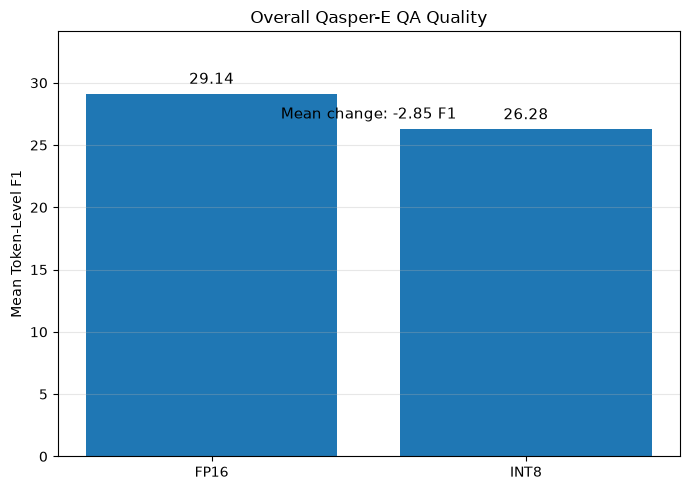

In [4]:
mean_fp16_f1 = comparison_df["fp16_f1"].mean()
mean_int8_f1 = comparison_df["int8_f1"].mean()
mean_f1_change = comparison_df["f1_change"].mean()


def bootstrap_mean_ci(values, samples=10_000, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    sampled_indices = rng.integers(
        0,
        len(values),
        size=(samples, len(values)),
    )
    bootstrap_means = values[sampled_indices].mean(axis=1)
    return (
        float(np.quantile(bootstrap_means, 0.025)),
        float(np.quantile(bootstrap_means, 0.975)),
    )

ci_lower, ci_upper = bootstrap_mean_ci(comparison_df["f1_change"])

labels = ["FP16", "INT8"]
values = [mean_fp16_f1, mean_int8_f1]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.text(
    0.5,
    max(values) - 2,
    f"Mean change: {mean_f1_change:.2f} F1",
    ha="center",
    fontsize=11,
)
ax.set_title("Overall Qasper-E QA Quality")
ax.set_ylabel("Mean Token-Level F1")
ax.set_ylim(0, max(values) + 5)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

figure_path = FIGURES_DIR / "qasper_e_overall_f1_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

 Mean F1 decreases from **29.14** with FP16 to **26.28** with INT8, a paired difference of **−2.85 F1 points**. The 95% bootstrap confidence interval is **[−5.13, −0.69]** and does not include zero. This supports the conclusion that uniform INT8 KV-cache quantization causes a measurable average quality loss on this evaluation set.

## 5. Per-example outcome changes

The average score does not show how many individual examples improve, remain unchanged, or degrade.

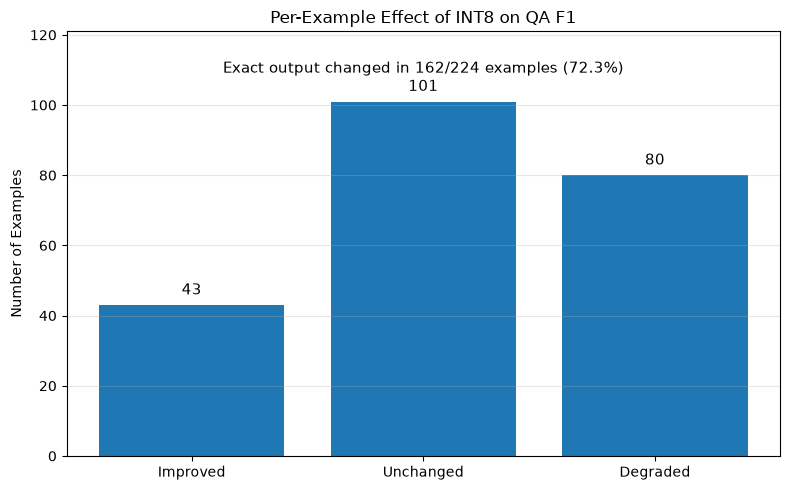

In [5]:
outcome_labels = ["Improved", "Unchanged", "Degraded"]
outcome_values = [
    int(improved_mask.sum()),
    int(unchanged_mask.sum()),
    int(degraded_mask.sum()),
]
changed_outputs = int((~comparison_df["outputs_identical"]).sum())
changed_outputs_percent = 100 * changed_outputs / len(comparison_df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_labels, outcome_values)

for bar, value in zip(bars, outcome_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.text(
    0.5,
    0.93,
    (
        f"Exact output changed in {changed_outputs}/224 examples "
        f"({changed_outputs_percent:.1f}%)"
    ),
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
)
ax.set_title("Per-Example Effect of INT8 on QA F1")
ax.set_ylabel("Number of Examples")
ax.set_ylim(0, max(outcome_values) + 20)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

figure_path = FIGURES_DIR / "qasper_e_outcome_counts_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

INT8 improves 43 examples, leaves 101 examples unchanged in F1, and degrades 80 examples. However, the exact generated text changes in **162 of 224 examples (72.3%)**. Numerical differences in the KV cache therefore alter the generation trajectory frequently, even when the final token-overlap score is unchanged.

## 6. Quality by context length

The next comparison groups examples by prompt length. The very small 0–2K bucket is shown but should not be treated as statistically representative because it contains only two examples.

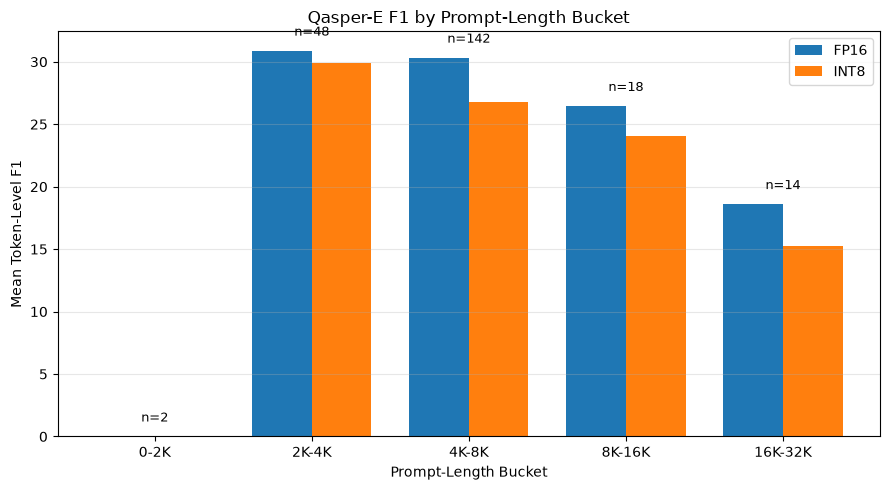

In [6]:
BUCKET_ORDER = ["0-2K", "2K-4K", "4K-8K", "8K-16K", "16K-32K"]
comparison_df["length_bucket"] = pd.Categorical(
    comparison_df["fp16_length_bucket"],
    categories=BUCKET_ORDER,
    ordered=True,
)

quality_by_length = (
    comparison_df
    .groupby("length_bucket", observed=False)
    .agg(
        examples=("dataset_index", "count"),
        fp16_mean_f1=("fp16_f1", "mean"),
        int8_mean_f1=("int8_f1", "mean"),
        mean_f1_change=("f1_change", "mean"),
    )
    .reset_index()
)

plot_df = quality_by_length[quality_by_length["examples"] > 0].copy()
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x - width / 2,
    plot_df["fp16_mean_f1"],
    width,
    label="FP16",
)
ax.bar(
    x + width / 2,
    plot_df["int8_mean_f1"],
    width,
    label="INT8",
)

for index, count in enumerate(plot_df["examples"]):
    ax.text(
        index,
        max(
            plot_df.iloc[index]["fp16_mean_f1"],
            plot_df.iloc[index]["int8_mean_f1"],
        ) + 1.2,
        f"n={count}",
        ha="center",
        fontsize=9,
    )

ax.set_title("Qasper-E F1 by Prompt-Length Bucket")
ax.set_xlabel("Prompt-Length Bucket")
ax.set_ylabel("Mean Token-Level F1")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["length_bucket"].astype(str))
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "qasper_e_f1_by_length_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

pearson_corr = comparison_df["fp16_prompt_tokens"].corr(
    comparison_df["f1_change"],
    method="pearson",
)
spearman_corr = (
    comparison_df["fp16_prompt_tokens"].rank()
    .corr(comparison_df["f1_change"].rank())
)

INT8 obtains lower mean F1 in every sufficiently populated context-length bucket. The average gaps are approximately **−1.01** for 2K–4K, **−3.53** for 4K–8K, **−2.37** for 8K–16K, and **−3.33** for 16K–32K.

The degradation is not monotonic with prompt length. Pearson correlation (**−0.002**) and Spearman correlation (**−0.015**) are both effectively zero. The results therefore do not support the stronger claim that longer prompts directly cause larger INT8 degradation.

## 7. Distribution and severity of F1 changes

This histogram shows whether the mean loss comes from many small changes or from a smaller number of severe regressions.

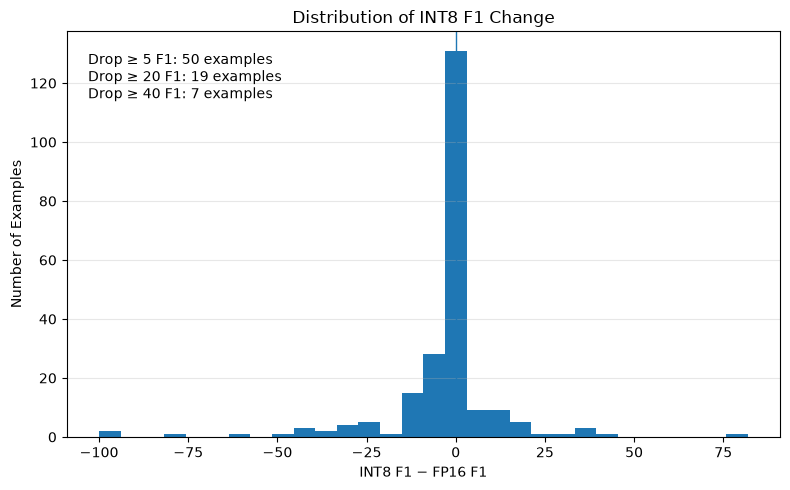

In [7]:
drop_5 = int((comparison_df["f1_change"] <= -5).sum())
drop_20 = int((comparison_df["f1_change"] <= -20).sum())
drop_40 = int((comparison_df["f1_change"] <= -40).sum())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comparison_df["f1_change"], bins=30)
ax.axvline(0, linewidth=1)

severity_text = (
    f"Drop ≥ 5 F1: {drop_5} examples\n"
    f"Drop ≥ 20 F1: {drop_20} examples\n"
    f"Drop ≥ 40 F1: {drop_40} examples"
)
ax.text(
    0.03,
    0.95,
    severity_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
)
ax.set_title("Distribution of INT8 F1 Change")
ax.set_xlabel("INT8 F1 − FP16 F1")
ax.set_ylabel("Number of Examples")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

figure_path = FIGURES_DIR / "qasper_e_f1_change_distribution_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

Many examples are concentrated near zero, which explains the median F1 change of zero. However, the distribution has a substantial negative tail: **50 examples** lose at least 5 points, **19 examples** lose at least 20 points, and **7 examples** lose at least 40 points. The average loss therefore includes a limited but important set of severe regressions.

## 8. End-to-end latency

This section compares sequential-request latency by prompt-length bucket. The metric includes both prefill and decoding.

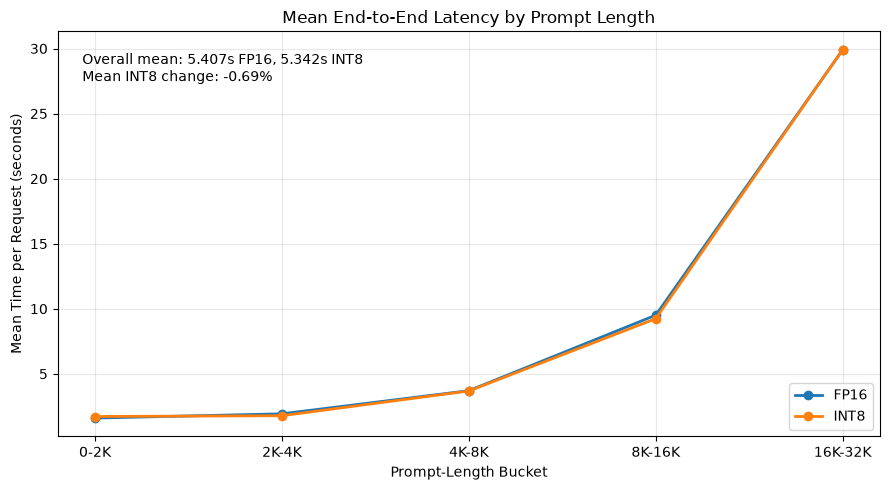

In [8]:
performance_by_length = (
    comparison_df
    .groupby("length_bucket", observed=False)
    .agg(
        examples=("dataset_index", "count"),
        fp16_mean_time=("fp16_generation_time_seconds", "mean"),
        int8_mean_time=("int8_generation_time_seconds", "mean"),
    )
    .reset_index()
)

plot_df = performance_by_length[performance_by_length["examples"] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    plot_df["length_bucket"].astype(str),
    plot_df["fp16_mean_time"],
    marker="o",
    linewidth=2,
    label="FP16",
)
ax.plot(
    plot_df["length_bucket"].astype(str),
    plot_df["int8_mean_time"],
    marker="o",
    linewidth=2,
    label="INT8",
)

mean_fp16_time = comparison_df["fp16_generation_time_seconds"].mean()
mean_int8_time = comparison_df["int8_generation_time_seconds"].mean()
mean_time_change = comparison_df["int8_time_change_percent"].mean()

ax.text(
    0.03,
    0.95,
    (
        f"Overall mean: {mean_fp16_time:.3f}s FP16, "
        f"{mean_int8_time:.3f}s INT8\n"
        f"Mean INT8 change: {mean_time_change:.2f}%"
    ),
    transform=ax.transAxes,
    va="top",
    fontsize=10,
)
ax.set_title("Mean End-to-End Latency by Prompt Length")
ax.set_xlabel("Prompt-Length Bucket")
ax.set_ylabel("Mean Time per Request (seconds)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "qasper_e_latency_by_length_clean.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

 Mean end-to-end time is **5.407 seconds** for FP16 and **5.342 seconds** for INT8. The average INT8 change is only **−0.69%**, so the two formats have nearly identical single-request latency. INT8 also generates slightly longer outputs on average, 30.8 tokens compared with 28.7 tokens.

For this workload, the main value of INT8 is therefore memory capacity rather than a substantial latency reduction.

## 9. Representative answer changes

The following examples show two of the largest INT8 regressions and one of the largest improvements. They illustrate how KV-cache quantization can change the generated answer rather than merely perturbing its score.

In [9]:
def format_references(references) -> str:
    references = normalize_references(references)
    if not references:
        return "No reference available"
    return " | ".join(str(reference) for reference in references)


def clean_markdown_text(text) -> str:
    return str(text).replace("\n", " ").strip()

selected_examples = pd.concat(
    [
        comparison_df.nsmallest(2, "f1_change"),
        comparison_df.nlargest(1, "f1_change"),
    ],
    ignore_index=True,
)

titles = [
    "Severe INT8 Regression 1",
    "Severe INT8 Regression 2",
    "Large INT8 Improvement",
]

cards = []

for title, (_, row) in zip(titles, selected_examples.iterrows()):
    cards.append(
        f"""
### {title}

**Prompt tokens:** {int(row['fp16_prompt_tokens']):,}

**Question:**  
{clean_markdown_text(row['question'])}

**Reference:**  
{clean_markdown_text(format_references(row['reference_answers']))}

**FP16 answer — F1 {row['fp16_f1']:.2f}:**  
{clean_markdown_text(row['fp16_answer'])}

**INT8 answer — F1 {row['int8_f1']:.2f}:**  
{clean_markdown_text(row['int8_answer'])}

**F1 change:** {row['f1_change']:.2f}
"""
    )

display(Markdown("\n\n---\n\n".join(cards)))


### Severe INT8 Regression 1

**Prompt tokens:** 5,615

**Question:**  
What BERT model do they test?

**Reference:**  
BERTbase | BERTbase

**FP16 answer — F1 100.00:**  
BERTBase

**INT8 answer — F1 0.00:**  
BERT-PN

**F1 change:** -100.00


---


### Severe INT8 Regression 2

**Prompt tokens:** 4,243

**Question:**  
Do they use graphical models?

**Reference:**  
No | No

**FP16 answer — F1 100.00:**  
No.

**INT8 answer — F1 0.00:**  
Yes.

**F1 change:** -100.00


---


### Large INT8 Improvement

**Prompt tokens:** 10,925

**Question:**  
Do they use number of votes as an indicator of preference?

**Reference:**  
No | Yes

**FP16 answer — F1 18.18:**  
Yes, they use the number of votes as an indicator of preference.

**INT8 answer — F1 100.00:**  
No.

**F1 change:** 81.82


 The extreme cases confirm that INT8 does not simply produce a small, uniform score shift. In some examples, quantization changes the answer trajectory enough to remove most or all overlap with the reference. In other examples, it can accidentally improve the answer. This variability is an important motivation for avoiding one uniform precision for every KV page.

## 10. Final discussion

The complete Qasper-E evaluation reveals a clear memory–quality trade-off.

Uniform INT8 KV-cache quantization reduces mean F1 from **29.14 to 26.28**, a paired loss of **2.85 points**. The 95% bootstrap confidence interval remains below zero, and several examples experience severe regressions. At the same time, sequential end-to-end latency changes very little.

These results complement the earlier memory-capacity experiments: INT8 can store substantially more KV-cache tokens in the same GPU memory, but applying the same low precision to every page is not an ideal quality trade-off.

This motivates the hierarchical design used in the next stage of the project:

- **HOT pages** remain at high precision.
- **WARM pages** are stored in INT8.
- **COLD pages** can later use more aggressive compression or offloading.

The goal is to preserve most of the memory-capacity benefit of INT8 while reducing the quality degradation observed with uniform quantization.